# Day 3 - Student Performance Analysis

Remote Internship Task

In this notebook, we analyze a dataset of 30 students to understand their
performance across attendance, assignments, midterms, and final scores.

We will:
1. Load the dataset
2. Look at its basic structure
3. Clean up missing/invalid values
4. Calculate averages, highest/lowest scores
5. Find students with low attendance and students at risk of failing
6. Compare performance across courses
7. Check if attendance is related to final score
8. Visualize everything with charts


## 1. Load the Dataset

We load `students.csv`, which contains 30 student records.
This file was generated separately using `generate_dataset.py`,
and includes a few missing/invalid values on purpose, so we can
practice cleaning data later in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame (a table-like structure)
df = pd.read_csv("students.csv")

# Show the first 5 rows just to get a quick look at the data
df.head()

,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Ali Raza,21.0,Male,Computer Science,64.0,82.0,90,40.0
1,Ayesha Khan,19.0,Female,Data Science,72.0,50.0,53,22.0
2,Bilal Ahmed,23.0,Male,Computer Science,51.0,63.0,59,57.0
3,Fatima Malik,19.0,Female,Artificial Intelligence,NaN,72.0,87,41.0
4,Hamza Sheikh,22.0,Male,Artificial Intelligence,74.0,88.0,88,61.0


## 2. Basic Information About the Dataset

Before doing any analysis, it's important to understand what we're working with:
how many rows/columns we have, what data types each column is, and whether
anything is missing.

In [2]:
# Shape tells us (number of rows, number of columns)
print("Shape of dataset:", df.shape)

print("\nColumn data types and non-null counts:")
df.info()

Shape of dataset: (30, 8)

Column data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_Name      30 non-null     str    
 1   Age               29 non-null     float64
 2   Gender            30 non-null     str    
 3   Course            30 non-null     str    
 4   Attendance        28 non-null     float64
 5   Assignment_Score  29 non-null     float64
 6   Midterm_Score     30 non-null     int64  
 7   Final_Score       29 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


In [3]:
# describe() gives us quick statistics (mean, min, max, etc.)
# for all the numeric columns in one go
df.describe()

,Age,Attendance,Assignment_Score,Midterm_Score,Final_Score
count,29.000000,28.000000,29.000000,30.000000,29.000000
mean,20.655172,74.357143,72.724138,67.166667,52.517241
std,1.737730,20.363756,15.170216,21.365592,24.462246
min,18.000000,51.000000,43.000000,32.000000,20.000000
25%,19.000000,61.750000,63.000000,53.750000,34.000000
50%,21.000000,71.500000,74.000000,66.000000,54.000000
75%,22.000000,86.000000,86.000000,88.750000,71.000000
max,23.000000,150.000000,97.000000,95.000000,97.000000


In [4]:
# Let's check how many missing values each column has
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Student_Name        0
Age                 1
Gender              0
Course              0
Attendance          2
Assignment_Score    1
Midterm_Score       0
Final_Score         1
dtype: int64


## 3. Handle Missing or Invalid Values

We found two kinds of problems in the raw data:

- **Missing values** — some cells are simply empty (NaN)
- **Invalid values** — attendance is a percentage, so it should never be above 100.
  We found one student with an attendance of 150, which is clearly a data entry mistake.

**Our approach:**
1. First, we fix invalid attendance values (anything over 100%) by treating them as missing.
2. Then, we fill all missing numeric values with the **median** of that column.

We use the median instead of the mean because the median is less affected by
outliers/extreme values, so it gives a more "typical" replacement value.

In [5]:
# Step 1: Any attendance above 100 is invalid, so we mark it as missing (NaN)
invalid_attendance_count = (df["Attendance"] > 100).sum()
print(f"Found {invalid_attendance_count} invalid attendance value(s) above 100%.")

df.loc[df["Attendance"] > 100, "Attendance"] = np.nan

Found 1 invalid attendance value(s) above 100%.


In [6]:
# Step 2: Fill missing values in numeric columns with the column's median
numeric_columns = ["Age", "Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]

for column in numeric_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
    print(f"Filled missing values in '{column}' with median = {median_value}")

print("\nMissing values remaining after cleaning:")
print(df.isnull().sum())

Filled missing values in 'Age' with median = 21.0
Filled missing values in 'Attendance' with median = 71.0
Filled missing values in 'Assignment_Score' with median = 74.0
Filled missing values in 'Midterm_Score' with median = 66.0
Filled missing values in 'Final_Score' with median = 54.0

Missing values remaining after cleaning:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


## 4. Average Scores

Now that the data is clean, let's calculate the average (mean) score
for each of our three score columns.

In [7]:
avg_assignment = df["Assignment_Score"].mean()
avg_midterm = df["Midterm_Score"].mean()
avg_final = df["Final_Score"].mean()

print(f"Average Assignment Score : {avg_assignment:.2f}")
print(f"Average Midterm Score    : {avg_midterm:.2f}")
print(f"Average Final Score      : {avg_final:.2f}")

Average Assignment Score : 72.77
Average Midterm Score    : 67.17
Average Final Score      : 52.57


## 5. Highest and Lowest Scores

Let's find out which student scored the highest and which scored the lowest
on the final exam.

In [8]:
# idxmax() / idxmin() give us the row index of the max/min value,
# then we use .loc[] to get that full row

top_student = df.loc[df["Final_Score"].idxmax()]
lowest_student = df.loc[df["Final_Score"].idxmin()]

print("Student with the HIGHEST final score:")
print(f"  Name  : {top_student['Student_Name']}")
print(f"  Score : {top_student['Final_Score']}")

print("\nStudent with the LOWEST final score:")
print(f"  Name  : {lowest_student['Student_Name']}")
print(f"  Score : {lowest_student['Final_Score']}")

Student with the HIGHEST final score:
  Name  : Hassan Javed
  Score : 97.0

Student with the LOWEST final score:
  Name  : Omar Farooq
  Score : 20.0


## 6. Students with Attendance Below 75%

Attendance below 75% is often used as a warning sign in real schools/universities.
Let's filter our DataFrame to find these students.

In [9]:
low_attendance_students = df[df["Attendance"] < 75]

print(f"Number of students with attendance below 75%: {len(low_attendance_students)}")
low_attendance_students[["Student_Name", "Attendance"]]

Number of students with attendance below 75%: 21


,Student_Name,Attendance
0,Ali Raza,64.0
1,Ayesha Khan,72.0
2,Bilal Ahmed,51.0
3,Fatima Malik,71.0
4,Hamza Sheikh,74.0
5,Sana Iqbal,65.0
7,Zainab Hussain,56.0
8,Ahmed Butt,63.0
10,Hassan Javed,71.0
15,Nimra Siddiqui,71.0


## 7. Students at Risk of Failing

For this analysis, we define "at risk of failing" as any student whose
**final score is below 40**. This is a simple, clear threshold we chose
for this task.

In [10]:
at_risk_students = df[df["Final_Score"] < 40]

print(f"Number of at-risk students (Final Score < 40): {len(at_risk_students)}")
at_risk_students[["Student_Name", "Course", "Attendance", "Final_Score"]]

Number of at-risk students (Final Score < 40): 10


,Student_Name,Course,Attendance,Final_Score
1,Ayesha Khan,Data Science,72.0,22.0
6,Usman Tariq,Data Science,93.0,22.0
7,Zainab Hussain,Data Science,56.0,37.0
11,Iqra Yousaf,Artificial Intelligence,99.0,21.0
13,Laiba Naveed,Software Engineering,93.0,33.0
15,Nimra Siddiqui,Computer Science,71.0,34.0
16,Omar Farooq,Computer Science,74.0,20.0
21,Tayyaba Rasheed,Data Science,86.0,20.0
24,Yasir Nawaz,Artificial Intelligence,53.0,34.0
28,Faizan Riaz,Software Engineering,60.0,20.0


## 8. Average Final Score by Course

Let's group students by their course and see which course has
the highest/lowest average final score.

In [11]:
avg_by_course = df.groupby("Course")["Final_Score"].mean().sort_values(ascending=False)
print("Average Final Score by Course:")
avg_by_course

Average Final Score by Course:


Course
Computer Science           57.125000
Artificial Intelligence    55.888889
Software Engineering       53.833333
Data Science               42.000000
Name: Final_Score, dtype: float64

## 9. Relationship Between Attendance and Final Score

We use **correlation** to check if there's a relationship between attendance
and final score. Correlation values range from -1 to 1:

- Close to **+1** → strong positive relationship (more attendance = higher score)
- Close to **-1** → strong negative relationship (more attendance = lower score)
- Close to **0** → little to no relationship

In [12]:
correlation = df["Attendance"].corr(df["Final_Score"])
print(f"Correlation between Attendance and Final Score: {correlation:.3f}")

if correlation > 0.5:
    print("This suggests a fairly strong positive relationship.")
elif correlation > 0.2:
    print("This suggests a weak-to-moderate positive relationship.")
elif correlation > -0.2:
    print("This suggests little to no meaningful relationship in this dataset.")
else:
    print("This suggests a negative relationship.")

Correlation between Attendance and Final Score: -0.161
This suggests little to no meaningful relationship in this dataset.


## 10. Visualizations

Now let's create 3 charts to visualize our findings:

1. Distribution of final scores (histogram)
2. Average final score by course (bar chart)
3. Attendance vs final score (scatter plot)

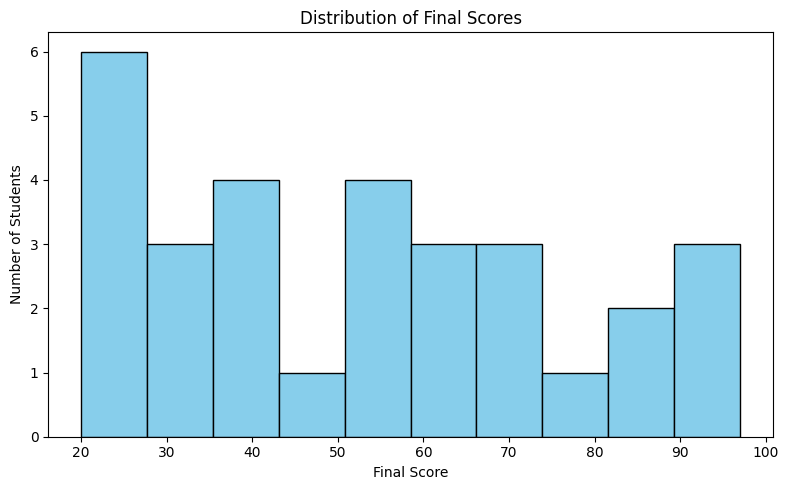

In [13]:
# Chart 1: Distribution of Final Scores
plt.figure(figsize=(8, 5))
plt.hist(df["Final_Score"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("chart1_score_distribution.png")
plt.show()

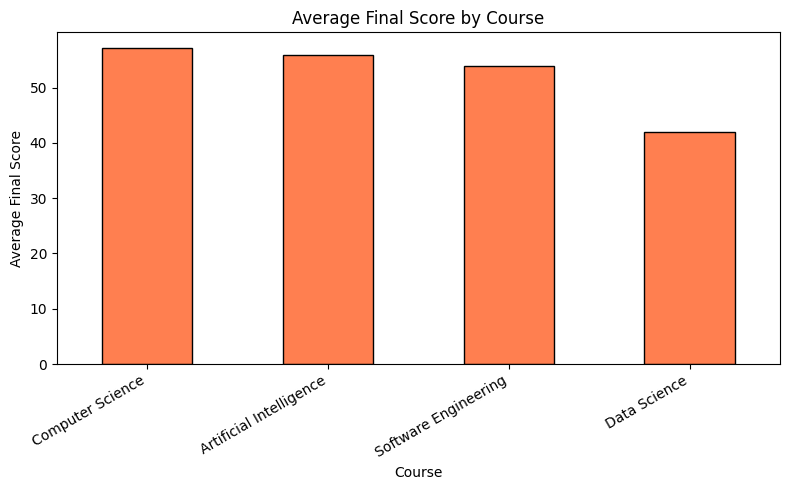

In [14]:
# Chart 2: Average Final Score by Course
plt.figure(figsize=(8, 5))
avg_by_course.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Average Final Score by Course")
plt.xlabel("Course")
plt.ylabel("Average Final Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("chart2_avg_score_by_course.png")
plt.show()

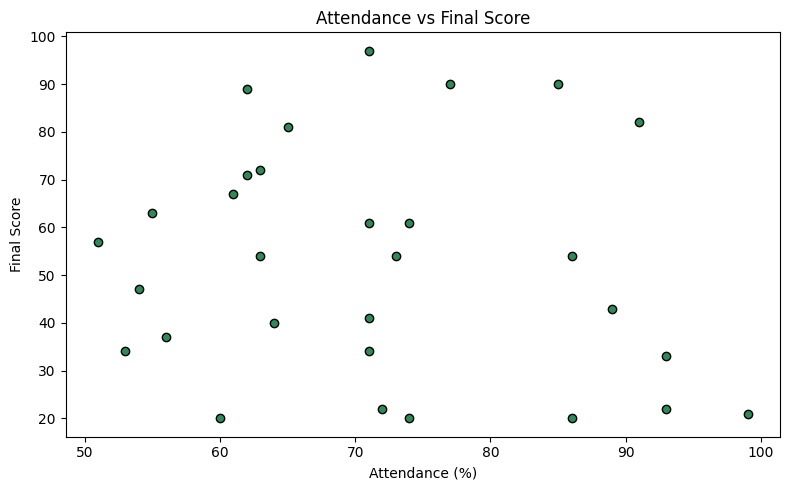

In [15]:
# Chart 3: Attendance vs Final Score
plt.figure(figsize=(8, 5))
plt.scatter(df["Attendance"], df["Final_Score"], color="seagreen", edgecolor="black")
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.tight_layout()
plt.savefig("chart3_attendance_vs_final_score.png")
plt.show()

## 11. Conclusion

**Summary of findings:**

- The dataset contains 30 students across 4 courses (Computer Science, Software
  Engineering, Data Science, and Artificial Intelligence).
- Before analysis, we found and fixed a few missing values and one invalid
  attendance entry (150%, which is not possible for a percentage) by treating
  it as missing and filling it with the column median.
- The average final score across all students came out to be a little over 50,
  showing a fairly wide spread in performance.
- Several students fall below the 75% attendance mark, and a separate group of
  students (final score below 40) were identified as at risk of failing —
  these two groups are worth checking, as they overlap for some students.
- Average final scores differ somewhat by course, though in this dataset the
  difference between the best and worst performing course is not very large.
- The correlation between attendance and final score in this particular dataset
  turned out to be weak. This is an honest finding — with real, larger datasets,
  we would generally expect a stronger positive relationship between attendance
  and performance, but with only 30 randomly generated records, no strong pattern
  emerged. This is a good reminder that correlation should always be checked with
  real data rather than assumed.

**What I practiced in this task:**
Loading data with Pandas, exploring it with `.info()` and `.describe()`,
cleaning missing/invalid values, filtering with conditions, grouping data,
calculating correlation, and creating basic charts with Matplotlib.